## clustering and other visualisations

In [16]:
import numpy as np
import pandas as pd
from sklearn import feature_extraction
import os, nltk, re, string, sklearn
pd.set_option('display.max_rows', 100)

In [17]:
base_dir = os.getcwd()
print(base_dir)
data = pd.read_csv('dataset.csv', usecols=['file', 'abstract'])

/Users/antique/Documents/GitHub/Sites/so-papers-simillarity


## preprocessing , tf-idf, k-means

In [18]:
#drop NaN rows
data = data[~data['abstract'].isna()].reset_index(drop=True)
data.head()

,file,abstract
0,Timur_Bachschi__Aniko_Hannak__Florian_Lemmeric...,Online knowledge platforms such as Stack Overf...
1,Sebastian_Baltes__Christoph_Treude__and_Martin...,Software engineering is knowledge-intensive an...
2,Sebastian_Baltes_and_Christoph_Treude__Code_Du...,Despite the unarguable importance of Stack Ove...
3,Sebastian_Baltes_and_Markus_Wagner__An_Annotat...,"To improve software engineering, software repo..."
4,Sengupta__S______Haythornthwaite__C__Learning_...,Stack Overflow (SO) has become a primary sourc...


In [19]:
import string
def text_preproc(texts = data['abstract']):
    #lower case
    texts = [text.lower() for text in texts]
    # Strip punctuation
    table = str.maketrans('', '', string.punctuation)
    texts = [text.translate(table) for text in texts]
    # removing all numbers to'num' 
    texts = [re.sub(r'\d+', '', text) for text in texts]
    #stopwords
    stopwords = set(nltk.corpus.stopwords.words('english') + ['reuter', '\x03'])
    texts = [[word for word in text.split() if word not in stopwords] for text in texts]
    #stemming
    stemmer = nltk.stem.PorterStemmer()
    texts = [" ".join([stemmer.stem(word) for word in text]) for text in texts]
    return texts
#--
texts = text_preproc(data['abstract'])

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(min_df=20, max_df=0.5, max_features=20000, ngram_range=(1,1), stop_words='english')
tfidf_matrix = vectorizer.fit_transform(texts)
print(tfidf_matrix.shape)
feature_matrix = tfidf_matrix

(74, 26)


### K-means algorithm for clustering

In [21]:
from scipy.cluster.vq import kmeans, vq
import seaborn as sns
import matplotlib.pyplot as plt
#num of clusters, top n terms in each cluster and feture matrix
def kmeans_cluster_terms(num_clusters, top_n, feature_matrix = tfidf_matrix):
    # cluster centers
    cluster_centers, distortion = kmeans(feature_matrix.todense(), num_clusters)
    # terms from tfidf_vectorizer 
    terms = vectorizer.get_feature_names()

    # Display the top_n terms in that cluster
    key_terms = []
    for i in range(num_clusters):
        # Sort the terms and print top_n terms
        center_terms = dict(zip(terms, list(cluster_centers[i])))
        sorted_terms = sorted(center_terms, key=center_terms.get, reverse=True)
        key_terms.append(sorted_terms[:top_n])

    # label the clusters
    labels, _ = vq(feature_matrix.todense(), cluster_centers, check_finite=True)

    return cluster_centers, distortion, key_terms, labels

### Elbow method for selecting the number of clusters

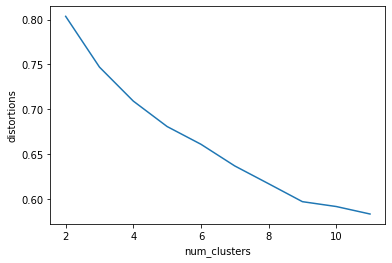

In [22]:
distortions = []
centroids = []
top_10 = []
cluster_labels = []

num_clusters = range(2, 12)

for i in num_clusters:
    cluster_centers, distortion, key_terms, labels = kmeans_cluster_terms(i, 10)
    centroids.append(cluster_centers)
    distortions.append(distortion)
    top_10.append(key_terms)
    cluster_labels.append(labels)

# plot the elbow plot
elbow_plot_data = pd.DataFrame({'num_clusters': num_clusters,
                               'distortions': distortions})

sns.lineplot(x='num_clusters', y='distortions', data = elbow_plot_data)
plt.show()

In [26]:
cluster_centers, distortion, key_terms, labels = kmeans_cluster_terms(5, 10)
print('Total papers: ',len(labels),'\nPaper labels: ', labels)
data['label']= labels
#---
fc = []
for i in range(0,5):
    inds = data[data['label']==i].index.tolist()
    print('\nCluster no# {} \nPapers: {}\n'.format(i, inds))
    print('Paper titles: \n')
    for x in inds:
        print(data.iloc[x]['file'][:50])
    fc.append(inds)

Total papers:  74 
Paper labels:  [0 2 1 1 1 3 2 2 3 2 3 1 2 1 0 1 2 1 3 1 1 3 0 2 0 2 3 3 2 2 0 3 2 3 0 4 3
 2 2 2 3 3 0 1 1 3 4 3 0 4 4 3 0 4 3 2 0 3 1 2 0 3 3 1 2 2 3 1 0 4 3 4 4 4]

Cluster no# 0 
Papers: [0, 14, 22, 24, 30, 34, 42, 48, 52, 56, 60, 68]

Paper titles: 

Timur_Bachschi__Aniko_Hannak__Florian_Lemmerich__a
Shaowei_Wang__Tse_Hsun_Chen__Ahmed__E__Hassan__How
Shaowei_Wang__David_Lo__Bogdan_Vasilescu__Alexande
Reza_Gharibi__Mohammad_Malekzadeh__Gamified_Incent
Srba__Ivan__Promoting_Sustainability_and_Transfera
Chunyang_Chen__Zhenchang_Xing__Mining_Technology_L
Lei_Xu__Tingting_Nian__Lu_s_Cabral__What_Makes_Gee
Dana_Movshovitz_Attias__Yair_Movshovitz_Attias__Pe
Ashton_Anderson__Dan_Huttenlocher__Jon_Kleinberg__
Scott_Grant_and_Buddy_Betts__2013__Encouraging_Use
Yla_Tausczik_and_James_Pennebaker__2012__Participa
Yla_Tausczik_and_James_Pennebaker__2011__Predictin

Cluster no# 1 
Papers: [2, 3, 4, 11, 13, 15, 17, 19, 20, 43, 44, 58, 63, 67]

Paper titles: 

Sebastian_Baltes_an

In [27]:
from sklearn.decomposition import PCA
pca = PCA()
components = pca.fit_transform(feature_matrix.todense())
xs, ys = components[:, 0], components[:, 1]

In [28]:
from sklearn.metrics import silhouette_samples, silhouette_score

def plot_kmeans(k, xs, ys, labels, cluster_names, cluster_colors, fig, ax, num_points=len(xs)):
    #create data frame that has the result of the PCA plus the cluster numbers
    df = pd.DataFrame(dict(x=xs[:num_points], y=ys[:num_points], label=labels[:num_points],
                           title=labels[:num_points]))

    groups = df.groupby('label')
    ax.margins(0.05)
    for name, group in groups:
        ax.plot(group.x, group.y, marker='o', linestyle='', ms=12,
                label=cluster_names[name], color=cluster_colors[name],
                mec='none')
        ax.set_aspect('auto')
        ax.tick_params(\
            axis= 'x',          
            which='both',       
            bottom='off',       
            top='off',          
            labelbottom='off')
        ax.tick_params(\
            axis= 'y',        
            which='both',      
            left='off',   
            top='off',      
            labelleft='off')

    ax.legend(numpoints=1)
    ax.set_title("K-means with " + str(k) + " clusters")
    ax.set_xlabel("first principal component")
    ax.set_ylabel("second principal component")

    return ax

def plot_silhouette(n_clusters, X, labels, cluster_colors, fig, ax):
    cluster_labels = np.asarray(labels)
    silhouette_avg = silhouette_score(X, cluster_labels)
    print("For n_clusters =", n_clusters,
            "The average silhouette_score is :", silhouette_avg)
    sample_silhouette_values = silhouette_samples(X, cluster_labels)
    y_lower = 10
    color = tuple(cluster_colors.values())
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        ax.fill_betweenx(np.arange(y_lower, y_upper),
                            0, ith_cluster_silhouette_values,
                            facecolor=color[i], edgecolor=color[i], alpha=0.7)
        ax.text(-0.02, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10
    ax.set_title("The silhouette plot for the various clusters.")
    ax.set_xlabel("The silhouette coefficient values")
    ax.set_ylabel("Cluster label")
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_yticks([])
    ax.set_xticks([])
    return ax

For n_clusters = 5 The average silhouette_score is : 0.15645327270312293


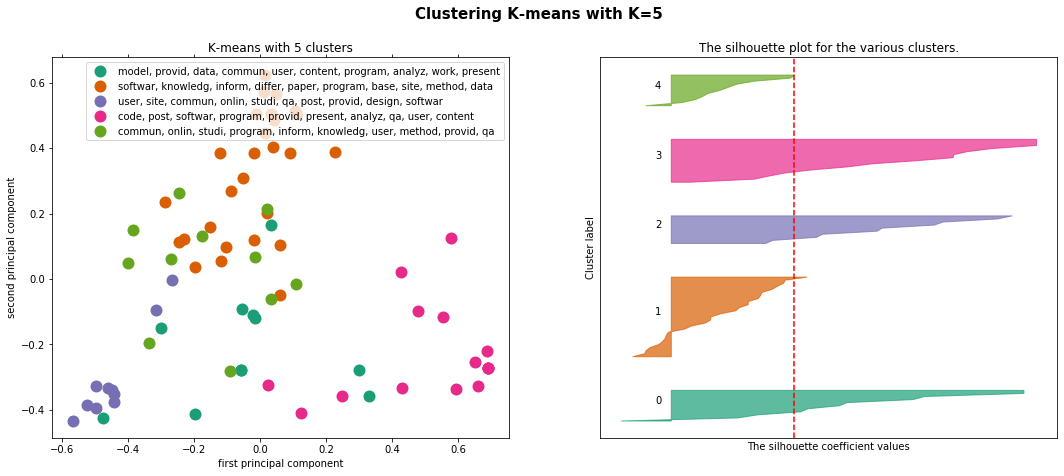

In [29]:
#set up colors per clusters using a dict
cluster_colors = {0: '#1b9e77', 1: '#d95f02', 2: '#7570b3', 3: '#e7298a', 4: '#66a61e'}

#set up cluster names using a dict
cluster_names = {0: ', '.join(top_10[3][0]),
                 1: ', '.join(top_10[3][1]),
                 2: ', '.join(top_10[3][2]),
                 3: ', '.join(top_10[3][3]),
                 4: ', '.join(top_10[3][4])
                }

# get the cluster labels
labels_four = list(cluster_labels[3])
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_size_inches(18, 7)

ax1 = plot_kmeans(5, xs, ys, labels_four, cluster_names, cluster_colors, fig, ax1, 250)
ax2 = plot_silhouette(5, feature_matrix.todense(), labels_four, cluster_colors, fig, ax2)

plt.suptitle("Clustering K-means with K=5", fontsize=15, fontweight='bold')
plt.show()